# Beanthentic AI Training Notebook

**Capstone use:** Train the **GI document ensemble** (bagging + boosting soft vote), export accuracy metrics, and evaluate the MoP qualitative IPOPHL engine.

**Product focus:** The admin app uses **GI document analysis only** (MoP qualitative review + optional document ensemble advisory).

**Ensemble theory in this project**
- **Bagging:** Random Forest + Extra Trees (reduce variance)
- **Boosting:** Gradient Boosting (reduce bias)
- **Combination:** Soft voting averages class probabilities → Ready / Not Ready advisory score

**Run Jupyter from the project root** (folder containing `web.py`).

| Section | Trains / evaluates |
|---------|-------------------|
| **A** | Document ensemble (JSON → `gi_document_model.joblib`) |
| **B** | MoP qualitative review (what IPOPHL cards show today) |
| **C** | Deploy + improvement workflow |


# Paper results snapshot (auto-refreshed 2026-08-15T21:16:55)

| Metric | Value |
|--------|-------|
| Model | Soft-voting ensemble (RF + Extra Trees + Gradient Boosting) |
| Training samples | 199 (Ready 66 / Not Ready 133) |
| Official MoP files | 7 |
| Hold-out test accuracy | **100.0%** |
| Cross-validation | **96.5% ± 5.8%** |
| Confusion matrix | [[27, 0], [0, 13]] |
| Training date | 2026-08-15T21:13:55.195582 |
| Artifact | `machinelearning/gi_document_model.joblib` |
| Metrics JSON | `machinelearning/document_training_results.json` |
| Figure | `machinelearning/document_confusion_matrix.png` |

**Note for the paper:** Dashboard Ready/Not Ready is driven by the MoP qualitative engine; the ensemble is the advisory ML layer evaluated above.


In [1]:
# Cell 1 — Setup paths (run first)
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split

# Project root = two levels up from this notebook
NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "web.py").exists():
    PROJECT_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent.parent / "web.py").exists():
    PROJECT_ROOT = NOTEBOOK_DIR.parent.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR  # adjust manually if needed

ML_DIR = PROJECT_ROOT / "machinelearning"
sys.path.insert(0, str(ML_DIR))
sys.path.insert(0, str(PROJECT_ROOT))

from ensemble_learning import (
    ENSEMBLE_DESCRIPTION,
    build_gi_ensemble,
    describe_ensemble,
    ensemble_feature_importances,
    ensemble_param_grid,
)

print("Project root:", PROJECT_ROOT)
print("ML dir:", ML_DIR)
print("Ensemble:", ENSEMBLE_DESCRIPTION)

Project root: C:\Users\Eliaza Mae Malibiran\OneDrive - Polytechnic University of the Philippines\Desktop\071626 - BEANTHENTIC\Beanthentic
ML dir: C:\Users\Eliaza Mae Malibiran\OneDrive - Polytechnic University of the Philippines\Desktop\071626 - BEANTHENTIC\Beanthentic\machinelearning
Ensemble: Soft-voting ensemble: Random Forest (bagging) + Extra Trees (bagging) + Gradient Boosting (boosting). Class probabilities are averaged; the majority-ready probability becomes the advisory ML score.


## Section A — IPOPHL document Random Forest

**Production baseline:** official Part 1, Part 2, and Control & Traceability files  
**Training artifacts:** `machinelearning/training_data/ipophl_official_mop_dataset.csv` and `machinelearning/training_data/gi_documents_raw.json`

The IPOPHL module now uses the official MoP qualitative review as the primary judge, with Random Forest as the default validation layer.

**Rebuild + retrain current production model:**
```powershell
python scripts/build_official_mop_dataset.py --train
```

In [2]:
manifest_path = ML_DIR / "training_data" / "official_mop_manifest.json"
results_path = ML_DIR / "document_training_results.json"
raw_path = ML_DIR / "training_data" / "gi_documents_raw.json"

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
results = json.loads(results_path.read_text(encoding="utf-8"))
dataset = json.loads(raw_path.read_text(encoding="utf-8"))

ready = sum(1 for d in dataset if d.get("label") == "Ready")
not_ready = len(dataset) - ready

print("Official files:", manifest["official_file_count"])
print("Official MoP training rows (pre-expand):", manifest["training_row_count"])
print(f"Expanded dataset labels: Ready={ready} | Not Ready={not_ready}")
print(f"Training set size: {results['sample_count']} (Ready={results['ready_count']} | Not Ready={results['not_ready_count']})")
print(f"Test accuracy: {results['accuracy']:.3f}")
print(f"CV mean ± std: {results['cv_mean']:.3f} ± {results['cv_std']:.3f}")
print("Best params:", results["best_params"])
print("Analysis method:", results.get("analysis_method"))
print("Training source:", results.get("training_source"))
print("Training date:", results.get("training_date"))
print("Ensemble:", results.get("ensemble_method"))

report = pd.DataFrame(results["classification_report"]).T
report


Official files: 7
Training rows: 19
Dataset labels: Ready=66 | Not Ready=133
Expanded training set: 199 (Ready=66 | Not Ready=133)
Test accuracy: 1.000
CV mean ± std: 0.965 ± 0.058
Best params: {'rf__max_depth': 12, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Analysis method: official_mop_ensemble_hybrid
Training source: ipophl_official_mop_dataset.csv
Training date: 2026-08-15T21:13:55.195582
Ensemble: soft_voting_bagging_boosting


,precision,recall,f1-score,support
0,1.000,1.000,1.000,27.000
1,1.000,1.000,1.000,13.000
accuracy,1.000,1.000,1.000,1.000
macro avg,1.000,1.000,1.000,40.000
weighted avg,1.000,1.000,1.000,40.000


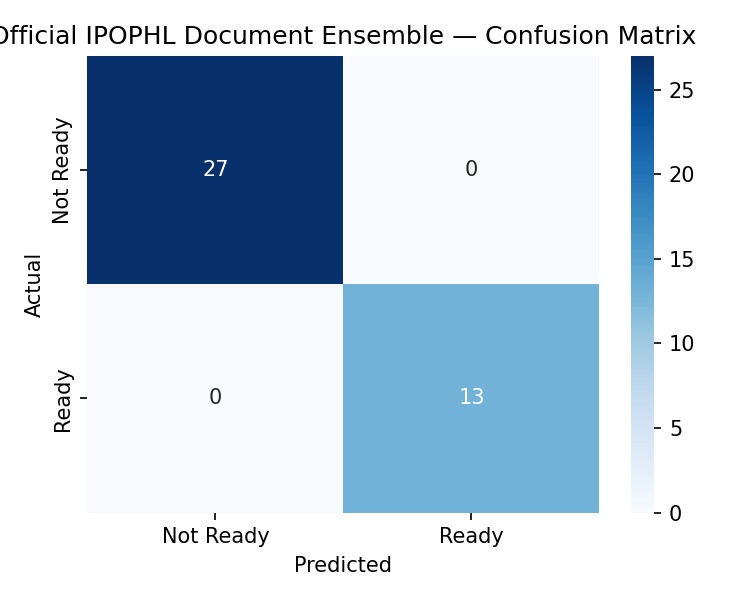

Saved: C:\Users\Eliaza Mae Malibiran\OneDrive - Polytechnic University of the Philippines\Desktop\071626 - BEANTHENTIC\Beanthentic\machinelearning\document_confusion_matrix.png
Hold-out accuracy: 100.0% | 5-fold CV: 96.5% ± 5.8%
Confusion matrix: [[27, 0], [0, 13]]


In [3]:
cm_doc = np.array(results["confusion_matrix"])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_doc,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Ready", "Ready"],
    yticklabels=["Not Ready", "Ready"],
)
plt.title("Official IPOPHL Document Ensemble — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(ML_DIR / "document_confusion_matrix.png", dpi=150)
plt.show()
print("Saved:", ML_DIR / "document_confusion_matrix.png")
print(
    f"Hold-out accuracy: {results['accuracy']:.1%} | "
    f"CV: {results['cv_mean']:.1%} ± {results['cv_std']:.1%}"
)
print("Confusion matrix:", results["confusion_matrix"])


## Section B — MoP qualitative engine (production IPOPHL cards)

This is the **authoritative** Ready / Not Ready logic on the dashboard (`gi_reference_basis.py`).  
Use this section to prove accuracy against your real MoP uploads or an expert-labeled test set.

In [4]:
from ai_engine import GIAnalyzer
from config.ipophl_store import OFFICIAL_IPOPHL_TASK_IDS, list_documents, resolve_file_path
from machinelearning.gi_reference_basis import evaluate_against_reference

analyzer = GIAnalyzer(str(ML_DIR), auto_train=False)

rows = []
for tid in OFFICIAL_IPOPHL_TASK_IDS:
    docs = list_documents(task_id=tid, limit=5)
    if not docs:
        rows.append({"task_id": tid, "file": "(none)", "status": "—", "word_count": 0, "missing": ""})
        continue
    rec = docs[0]
    path = resolve_file_path(rec["file_uuid"], filename_hint=rec.get("original_filename"))
    text = analyzer.extract_text_from_file(str(path)) if path else ""
    review = evaluate_against_reference(text, task_id=tid, term_matches=analyzer._term_matches)
    rows.append({
        "task_id": tid,
        "file": rec.get("original_filename") or (path.name if path else ""),
        "status": review["status"],
        "word_count": review["word_count"],
        "missing": ", ".join(review.get("missing_requirements") or [])[:80],
    })

mop_df = pd.DataFrame(rows)
display(mop_df)
print("Ready count:", (mop_df["status"] == "Ready").sum(), "/", len(OFFICIAL_IPOPHL_TASK_IDS))

# Authoritative official MoP labels from the rebuilt manifest
man_df = pd.DataFrame(manifest.get("files") or [])
display(man_df)
if not man_df.empty:
    print(
        "Official MoP qualitative Ready:",
        int((man_df["status"] == "Ready").sum()),
        "/",
        len(man_df),
    )


task_id,file,status,word_count,missing
phase1-introduction,(none),—,0,
phase1-history,(none),—,0,
phase1-physical-link,(none),—,0,
phase2-general,(none),—,0,
phase2-specific,(none),—,0,
phase2-production,(none),—,0,
phase3-control,(none),—,0,


Ready count: 0 / 7


sample_id,task_id,path,status,word_count
n1,phase1-introduction,reference\mop\PART 1 - Justification for the Request for Protection-20260724T153341Z-1-001\PART 1 - Justification for the Request for Protection\Introduction & Reputation.docx,Ready,1114
n2,phase1-history,reference\mop\PART 1 - Justification for the Request for Protection-20260724T153341Z-1-001\PART 1 - Justification for the Request for Protection\History of Kapeng Barako.docx,Ready,3921
n3,phase1-physical-link,reference\mop\PART 1 - Justification for the Request for Protection-20260724T153341Z-1-001\PART 1 - Justification for the Request for Protection\Physical link to the territory.docx,Ready,2403
n4,phase2-general,reference\mop\PART 2 - Technical Part-20260724T153344Z-1-001\PART 2 - Technical Part\TECHNICAL - General Description.docx,Ready,608
n5,phase2-specific,reference\mop\PART 2 - Technical Part-20260724T153344Z-1-001\PART 2 - Technical Part\TECHNICAL - Specific Description of the Production.docx,Not Ready,52
n6,phase2-production,reference\mop\PART 2 - Technical Part-20260724T153344Z-1-001\PART 2 - Technical Part\TECHNICAL - The Production Process.docx,Not Ready,2817
n7,phase3-control,reference\mop\CONTROL & TRACEABILITY & LABELLING.docx,Not Ready,73


Official MoP qualitative labels (n=7): Ready=4, Not Ready=3


### Expert validation (recommended for capstone)

Create `machinelearning/training_data/ipophl_expert_labels.csv`:

```csv
file_uuid,task_id,expected_status,reviewer
88b93a36-...,phase1-introduction,Ready,LGU Reviewer
```

Then compute agreement rate in a new cell:

```python
import csv
labels_path = ML_DIR / "training_data" / "ipophl_expert_labels.csv"
# compare expected_status vs system status → accuracy, confusion matrix
```

## Section C — Deploy models & improve the workflow

### Deploy to production (run in terminal after notebook metrics look good)

```powershell
# Rebuild official IPOPHL MoP dataset + retrain document ensemble
python scripts\build_official_mop_dataset.py --train

# Or train document model only
python machinelearning\train_ai_model.py --train-documents

# Re-score stored uploads after model or MoP changes
python scripts\build_document_training_data.py --reanalyze

# Restart app
python web.py
```

### Improvement cycle (document in Chapter 3 / Methodology)

1. Update the official Part 1 / Part 2 / Control documents or their labels  
2. Rebuild the official dataset and retrain the document ensemble  
3. Check notebook metrics and confusion matrix  
4. Reanalyze stored IPOPHL uploads  
5. Export JSON metrics and figures for the paper  

Full written guide: `docs/JUPYTER_ML_TRAINING_GUIDE.md`

In [5]:
# Optional: deploy document model from this notebook (uncomment to run)
# import joblib
# joblib.dump(doc_rf, ML_DIR / "gi_document_model.joblib")
# print("Saved gi_document_model.joblib — restart web.py")

# Check what the live app will report
status_path = ML_DIR / "document_training_results.json"
if status_path.exists():
    print("Current production document metrics:")
    print(json.dumps(json.loads(status_path.read_text(encoding="utf-8")), indent=2)[:1200])

Current production document metrics:
{
  "accuracy": 1.0,
  "cv_mean": 0.9648717948717949,
  "cv_std": 0.05828809178258876,
  "best_params": {
    "rf__max_depth": 12,
    "rf__min_samples_leaf": 1,
    "rf__min_samples_split": 2,
    "rf__n_estimators": 100
  },
  "classification_report": {
    "0": {
      "precision": 1.0,
      "recall": 1.0,
      "f1-score": 1.0,
      "support": 27.0
    },
    "1": {
      "precision": 1.0,
      "recall": 1.0,
      "f1-score": 1.0,
      "support": 13.0
    },
    "accuracy": 1.0,
    "macro avg": {
      "precision": 1.0,
      "recall": 1.0,
      "f1-score": 1.0,
      "support": 40.0
    },
    "weighted avg": {
      "precision": 1.0,
      "recall": 1.0,
      "f1-score": 1.0,
      "support": 40.0
    }
  },
  "confusion_matrix": [
    [
      27,
      0
    ],
    [
      0,
      13
    ]
  ],
  "training_date": "2026-08-15T21:13:55.195582",
  "model_type": "document_ensemble",
  "sample_count": 199,
  "ready_count": 66,
  "not_read